# 15.2.1 固定采样间隔的一步映射

## 学习目标与先修知识

把状态（state）与输入（input）组成离散转移，分清一步拟合的训练和留出轨迹（trajectory）。

先修：15.1 小网络；14.5 独立评估；离散更新。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

每隔固定时间观测（observation）一次物质总量。若网络直接预测下一次观测，它学到的是一步状态映射，还是连续变化率？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
print([.85*x+.2*.4+.06*np.tanh(x) for x in [0.,.5,1.]])

[np.float64(0.08000000000000002), np.float64(0.5327270294356006), np.float64(0.9756956493573459)]


## 模型假设

采样（sampling）间隔固定为 1 T；x 和 u 都记录为以 U 为单位的数值。a、b 无量纲（dimensionless），q 的单位是 U；tanh 的自变量是 x/(1 U)；代码中的 x 是以 U 计的数值，写 tanh(x) 就表示先除以 1 U。训练与评估使用不同完整轨迹。改变采样间隔时必须重建映射或检验迁移。

## 数学解释与推导

教学映射为 $x_{n+1}=a x_n+b u_n+q\tanh(x_n/(1\,U))$。给定配对 $(x_n,u_n,x_{n+1})$，一步损失是 $\sum_n[\hat F(x_n,u_n)-x_{n+1}]^2/N$。每次预测都使用真实的 $x_n$，这是教师强制（teacher forcing）；它与从一个初值（initial condition）递推得到的自由轨迹不是同一任务。若目标是所追踪物质总量（tracked amount），检查预测是否非负，负值不能仅用低训练损失掩盖。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def discrete_step(x, u, a, b, q):
    """x and u are numerical values in U; tanh(x) means tanh(x_phys/(1 U))."""
    return float(a*x + b*u + q*math.tanh(x))


def teacher_forced(states, inputs, a, b, q):
    return [discrete_step(float(x), float(u), a, b, q)
            for x, u in zip(states[:-1], inputs)]


def discrete_roll(x0, inputs, a, b, q):
    states = [float(x0)]
    for u in inputs:
        states.append(discrete_step(states[-1], float(u), a, b, q))
    return states

## 对照实验

先对同一组参数（parameter）比较一步预测（one-step-ahead prediction）与自由运行（free-run simulation）；再用训练轨迹估计三个系数，检查新初值下的滚动误差。

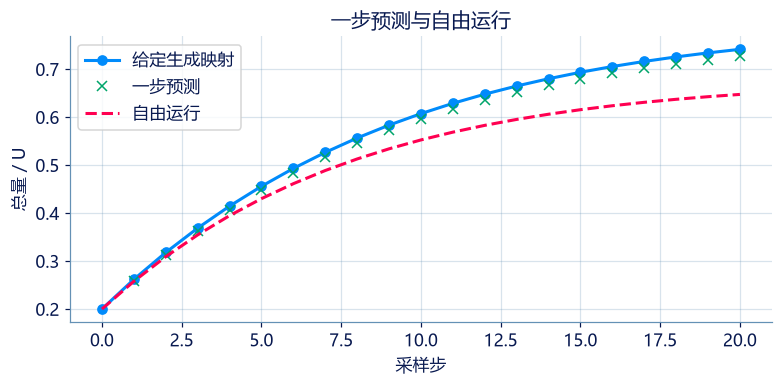

训练列秩： 3 ；估计系数： [0.85 0.2  0.06] ；新初值 RMSE： 4.700394457009017e-15


In [4]:
inputs=[.4]*20;truth=np.asarray(discrete_roll(.2,inputs,.85,.2,.06));one=np.asarray(teacher_forced(truth,inputs,.83,.2,.06));free=np.asarray(discrete_roll(.2,inputs,.83,.2,.06));t=np.arange(21)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(t,truth,"o-",label="给定生成映射",color=BLUE);ax.plot(t[1:],one,"x",label="一步预测",color=GREEN);ax.plot(t,free,"--",label="自由运行",color=PINK);ax.set(xlabel="采样步",ylabel="总量 / U",title="一步预测与自由运行");ax.legend();ax.grid(alpha=.25);plt.show()

# The fixed tanh feature makes the three coefficients a transparent,
# trainable nonlinear transition family.
train_inputs=np.tile([.1,.6,.25,.8],8)
train_path=np.asarray(discrete_roll(.2,train_inputs,.85,.2,.06))
design=np.column_stack([train_path[:-1],train_inputs,np.tanh(train_path[:-1])])
estimated=np.linalg.lstsq(design,train_path[1:],rcond=None)[0]
held_inputs=np.tile([.6,.1,.8,.25],8)
held_truth=np.asarray(discrete_roll(1.4,held_inputs,.85,.2,.06))
held_prediction=np.asarray(discrete_roll(1.4,held_inputs,*estimated))
print("训练列秩：",np.linalg.matrix_rank(design),"；估计系数：",estimated,
      "；新初值 RMSE：",np.sqrt(np.mean((held_prediction-held_truth)**2)))


## 结果解释

一步预测（one-step-ahead prediction）每次获得真实当前状态，自由运行（free-run simulation）只能使用自身上一步结果。同一组参数（parameter）因此可能产生不同的一步误差和滚动误差。 固定 tanh 特征的三个系数由训练轨迹求出；列秩（rank）充足时可在这组无噪声数据上恢复生成映射，留出初值仍需独立检验。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
a,b,q=.85,.2,.06
assert discrete_step(0.,0.,a,b,q)==0.
np.testing.assert_allclose(teacher_forced(truth,inputs,a,b,q),truth[1:])
assert len(discrete_roll(.2,[],a,b,q))==1
print("已知映射、空输入及一步配对核验通过。")
assert np.linalg.matrix_rank(design)==3
np.testing.assert_allclose(estimated,[.85,.2,.06],atol=1e-10)
np.testing.assert_allclose(held_prediction,held_truth,atol=1e-10)
print("训练系数与新初值滚动已独立核对。")


已知映射、空输入及一步配对核验通过。
训练系数与新初值滚动已独立核对。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：一步预测喂入什么

评估一步映射时给模型（model）真实 x_n，结果可以直接称为自由滚动吗？

- **A.** 不可以；自由滚动从初值（initial condition）起只能使用自身上一时刻预测。
- **B.** 可以，只要两者共用权重。
- **C.** 可以，只要画在同一坐标轴。
- **D.** 可以，因为时间间隔固定。

[作答：一步预测喂入什么](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-one-step-input)

### 第 2 题 · 单项选择题：采样间隔变化后的模型

在 1 T 间隔学到的下一步映射，改成 0.5 T 采样（sampling）后应如何使用？

- **A.** 直接把输出（output）解释为连续导数（derivative）。
- **B.** 核验或重建新间隔的映射，不能无条件沿用。
- **C.** 只把图线拉宽。
- **D.** 不用声明间隔。

[作答：采样间隔变化后的模型](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-sampling-object)

### 第 3 题 · Python 计算题：固定间隔的一步状态

按题给映射计算单步新状态（state）；x、u 数值以 U 为单位。

**函数与代码模板**

```python
def solve(
    x: float,
    u: float,
    a: float,
    b: float,
    q: float,
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前总量。 | U |
| `u` | `float` | 本步输入（input）量。 | U |
| `a` | `float` | 保留系数。 | 1 |
| `b` | `float` | 输入系数。 | 1 |
| `q` | `float` | 平滑修正幅度。 | U |

**返回值**

直接返回 next_state（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_state` | `float` | 一步后的总量。 | U |

**计算规则**

下一状态 = a*x+b*u+q*tanh(x)，x 是以 1 U 为基准的数值。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前总量。 | 0 | U |
| u | 本步输入（input）量。 | 1 | U |
| a | 保留系数。 | 0.8 | 1 |
| b | 输入系数。 | 0.2 | 1 |
| q | 平滑修正幅度。 | 0.1 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.0
u = 1.0
a = 0.8
b = 0.2
q = 0.1

result = solve(x, u, a, b, q)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_state | 一步后的总量。 | 0.2 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.2
```

**样例解释**

零状态下 tanh(0)=0；此函数返回下一步状态，不返回变化率。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定间隔的一步状态](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-fixed-map)

### 第 4 题 · Python 计算题：真实旧状态的一步预测

对每一对真实旧状态（state）与输入（input）计算一步候选预测。

**函数与代码模板**

```python
def solve(
    states: list[float],
    inputs: list[float],
    a: float,
    b: float,
    q: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | N+1 个真实状态。 | U |
| `inputs` | `list[float]` | N 个本步输入。 | U |
| `a` | `float` | 状态系数。 | 1 |
| `b` | `float` | 输入系数。 | 1 |
| `q` | `float` | 修正幅度。 | U |

**返回值**

直接返回 prediction（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prediction` | `list[float]` | N 个一步预测（one-step-ahead prediction），不含初态。 | U |

**计算规则**

第 n 项预测 = a*states[n]+b*inputs[n]+q*tanh(states[n])。

**约束与边界**

- len(states)=len(inputs)+1，步数 0—100，全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| states | N+1 个真实状态。 | [1.0, 2.0, 3.0] | U |
| inputs | N 个本步输入。 | [0.5, 0.0] | U |
| a | 状态系数。 | 0.8 | 1 |
| b | 输入系数。 | 0.2 | 1 |
| q | 修正幅度。 | 0 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
states = [1.0, 2.0, 3.0]
inputs = [0.5, 0.0]
a = 0.8
b = 0.2
q = 0.0

result = solve(states, inputs, a, b, q)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| prediction | N 个一步预测（one-step-ahead prediction），不含初态。 | [0.9, 1.6] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.9, 1.6]
```

**样例解释**

每个预测使用输入 states[n]；空步数时返回空列表。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：真实旧状态的一步预测](http://127.0.0.1:8000/chapters/15-02-%E7%A6%BB%E6%95%A3%E5%8A%A8%E5%8A%9B%E5%AD%A6%E5%AD%A6%E4%B9%A0/practice/?question=p15-teacher-forced)

**进一步阅读**

[神经微分方程原论文](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)把连续右端与离散网络层作对照。